In [1]:
import pandas as pd


In [2]:
product_category_df = pd.read_csv("cleaned_product_category.csv")
sellers_df = pd.read_csv("cleaned_sellers.csv")
products_df = pd.read_csv("cleaned_products.csv")
orders_df = pd.read_csv("cleaned_Orders.csv")
order_reviews_df = pd.read_csv("cleaned_order_reviews.csv")
order_payments_df = pd.read_csv("cleaned_order_payments.csv")
geolocation_df= pd.read_csv("cleaned_geolocation.csv")
order_items_df = pd.read_csv("cleaned_OrderItems.csv")
customers_df = pd.read_csv("cleaned_Customers.csv")

In [3]:
Revenue = order_payments_df["payment_value"]

In [4]:
Revenue

0          99.33
1          24.39
2          65.71
3         107.78
4         128.45
           ...  
103881    363.31
103882     96.80
103883     47.77
103884    369.54
103885    191.58
Name: payment_value, Length: 103886, dtype: float64

In [5]:
import matplotlib.pyplot as plt

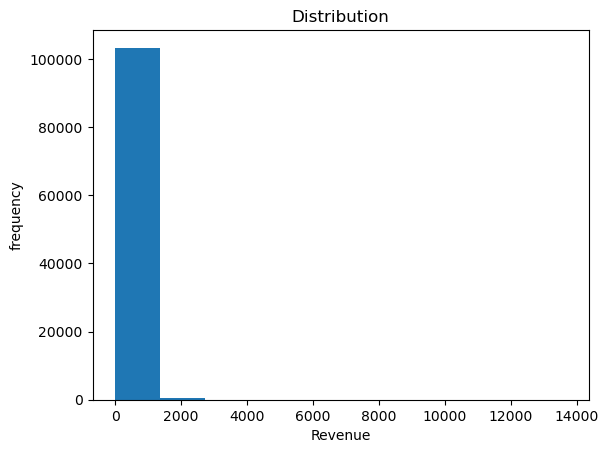

In [6]:
plt.hist(Revenue)
plt.xlabel("Revenue")
plt.ylabel("frequency")
plt.title("Distribution")
plt.show()

In [7]:
import seaborn as sns

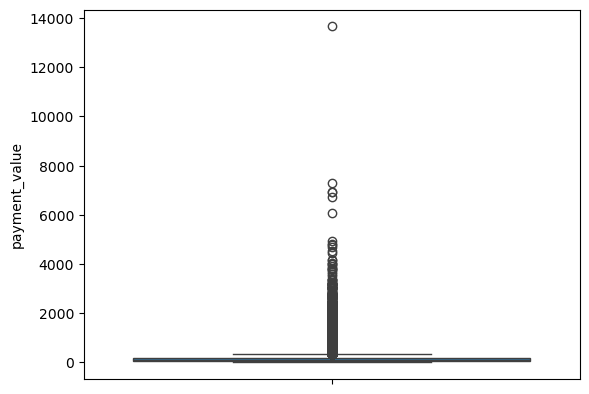

In [8]:
sns.boxplot(Revenue)
plt.show()

In [9]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [10]:
# i will convert  orders time datatime values as they are string form right now.


In [11]:
import pandas as pd
orders_df["order_purchase_timestamp"] = pd.to_datetime(orders_df["order_purchase_timestamp"]) 
orders_df["order_delivered_customer_date"] = pd.to_datetime(orders_df["order_delivered_customer_date"])

In [12]:
orders_df["delivery_time"] = (
    orders_df["order_delivered_customer_date"]
    - orders_df["order_purchase_timestamp"]
).dt.days

In [13]:
Delivery = orders_df["delivery_time"]

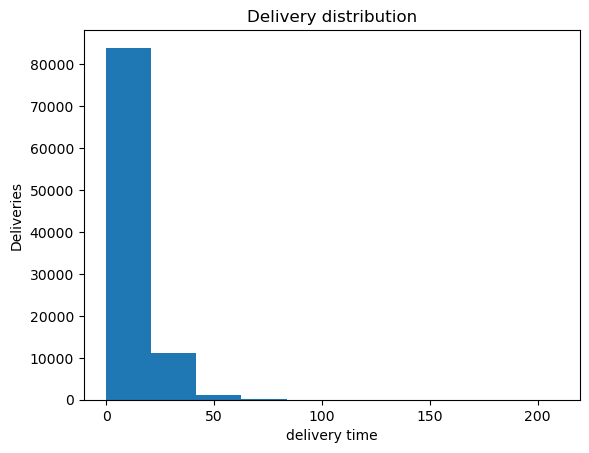

In [14]:
plt.hist(Delivery)
plt.xlabel("delivery time")
plt.ylabel("Deliveries")
plt.title('Delivery distribution')
plt.show()

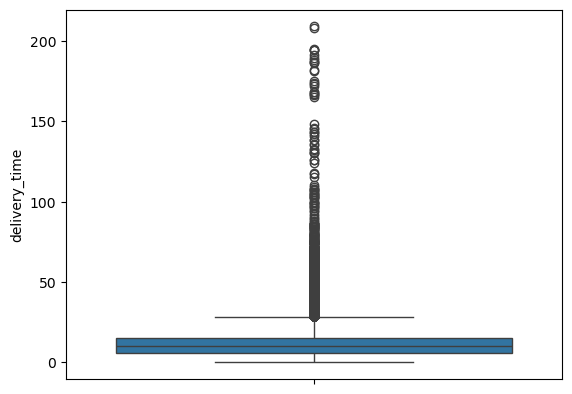

In [15]:
sns.boxplot(Delivery)
plt.show()

In [16]:
Reviews = order_reviews_df["review_score"]

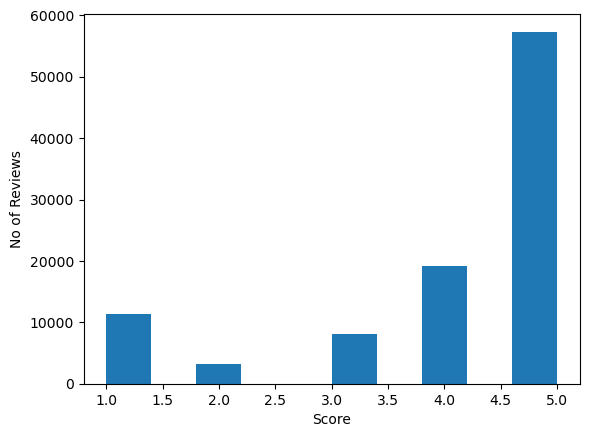

In [17]:
plt.hist(Reviews)
plt.xlabel('Score')
plt.ylabel('No of Reviews')
plt.show()

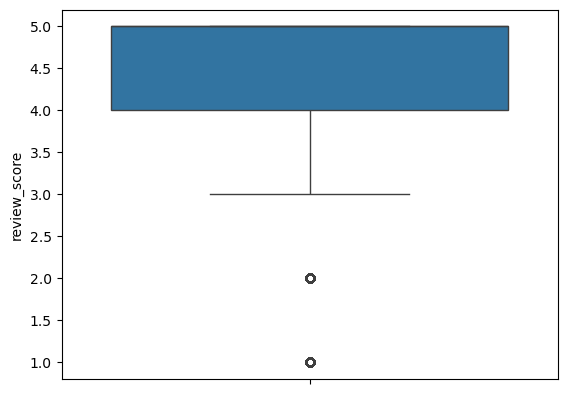

In [18]:
sns.boxplot(Reviews)
plt.show()

In [19]:
# for comparison i think scatter plot is good for delivery vs reviews


In [20]:
#have to merge bec x and y were not equal so i had to merge it.

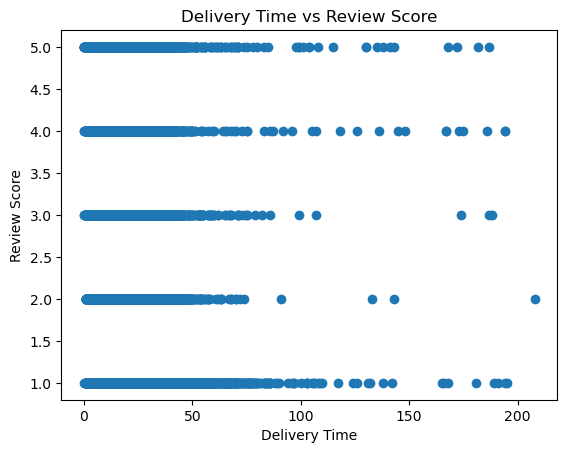

In [21]:
df = orders_df.merge(
    order_reviews_df[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

plt.scatter(df["delivery_time"], df["review_score"])
plt.xlabel("Delivery Time")
plt.ylabel("Review Score")
plt.title("Delivery Time vs Review Score")
plt.show()

In [22]:
# for price vs category i will merge order items and products as they have similar product id ( and they have price and category )


In [27]:
price_category_df = order_items_df.merge(
    products_df[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

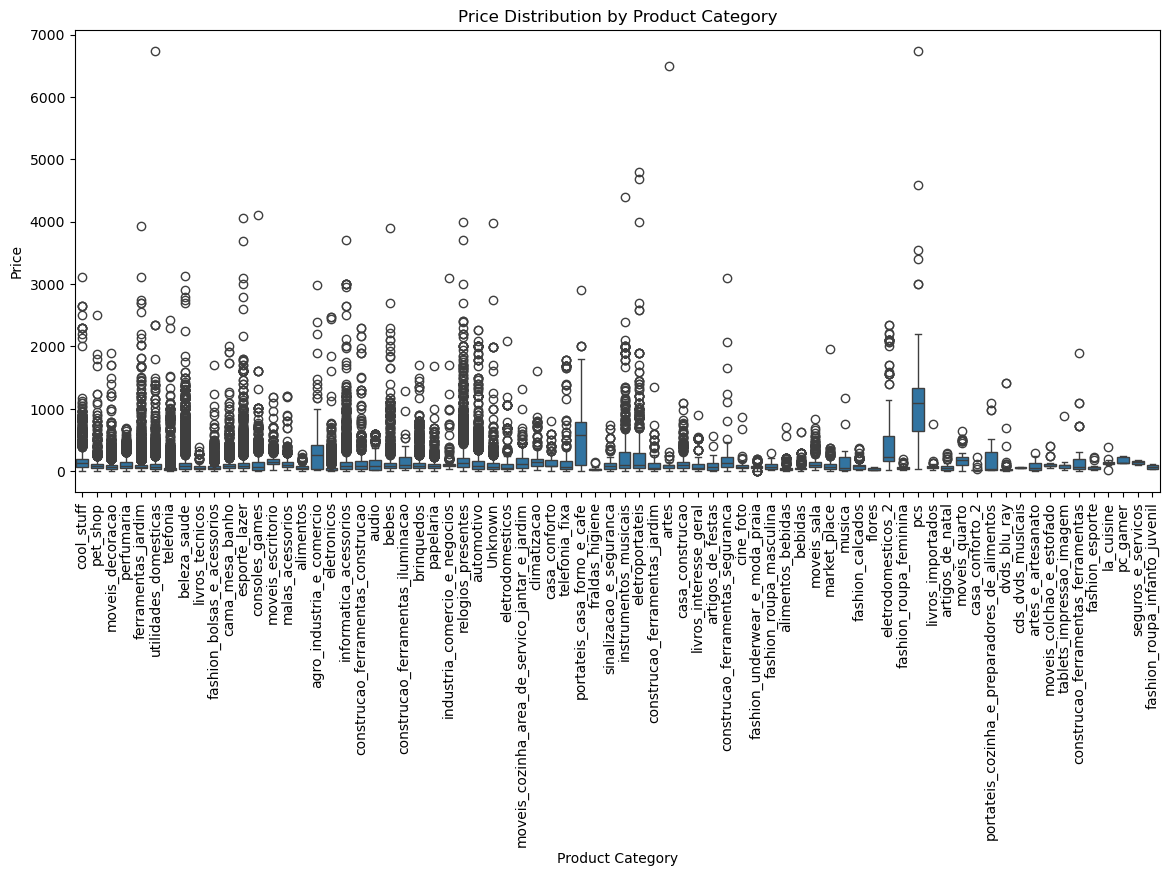

In [28]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=price_category_df,
    x="product_category_name",
    y="price"
)

plt.xticks(rotation=90)
plt.xlabel("Product Category")
plt.ylabel("Price")
plt.title("Price Distribution by Product Category")
plt.show()

In [29]:
# now task 2


In [30]:
orders_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0
...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,8.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,22.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,24.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0


In [31]:
orders_df["order_purchase_timestamp"] = pd.to_datetime(
    orders_df["order_purchase_timestamp"]
)

In [32]:
#counting orders by month

monthly_orders = (
    orders_df
    .set_index("order_purchase_timestamp")
    .resample("ME")["order_id"]
    .count()
)

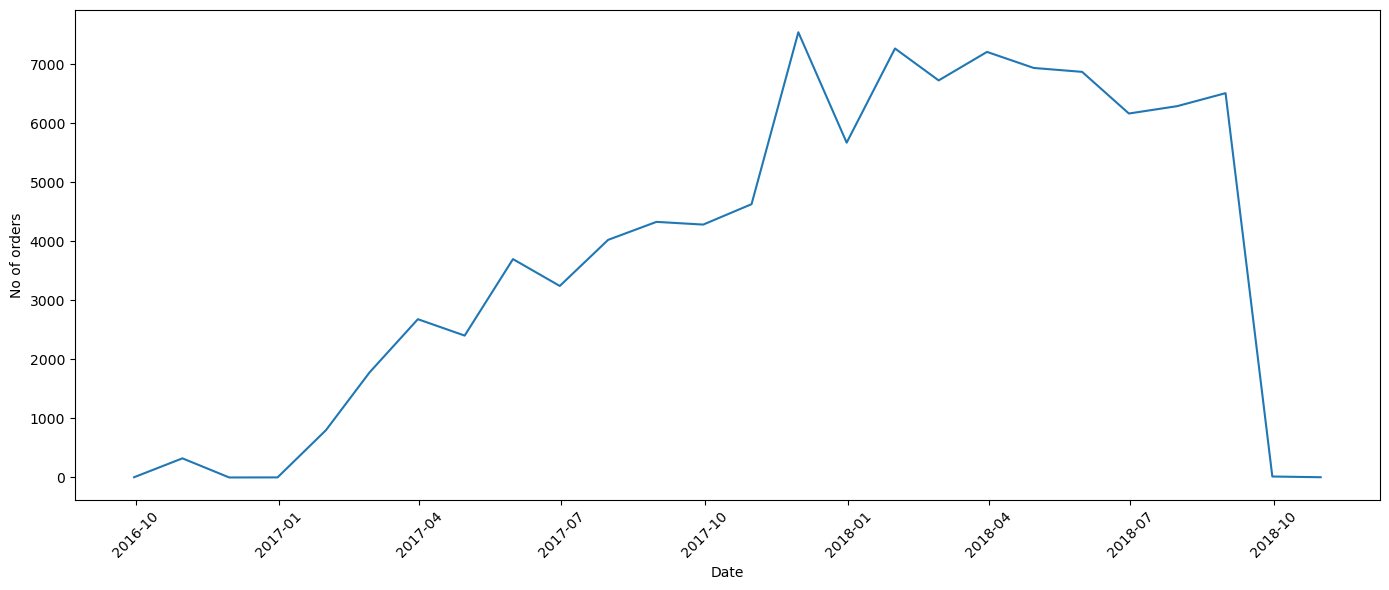

In [33]:
plt.figure(figsize=(14,6))
plt.plot(monthly_orders.index, monthly_orders.values)
plt.xlabel("Date")
plt.ylabel("No of orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# orders by state i will merge customer and orders bec customers have state in it and customer id and order have customer id in it


In [35]:
orders_by_state = orders_df.merge(
    customers_df[["customer_id","customer_state"]],
    on="customer_id",
    how="left"
)

In [36]:
orders_by_state_df = (
    orders_by_state["customer_state"]
    .value_counts()
    .sort_values(ascending=False)
)

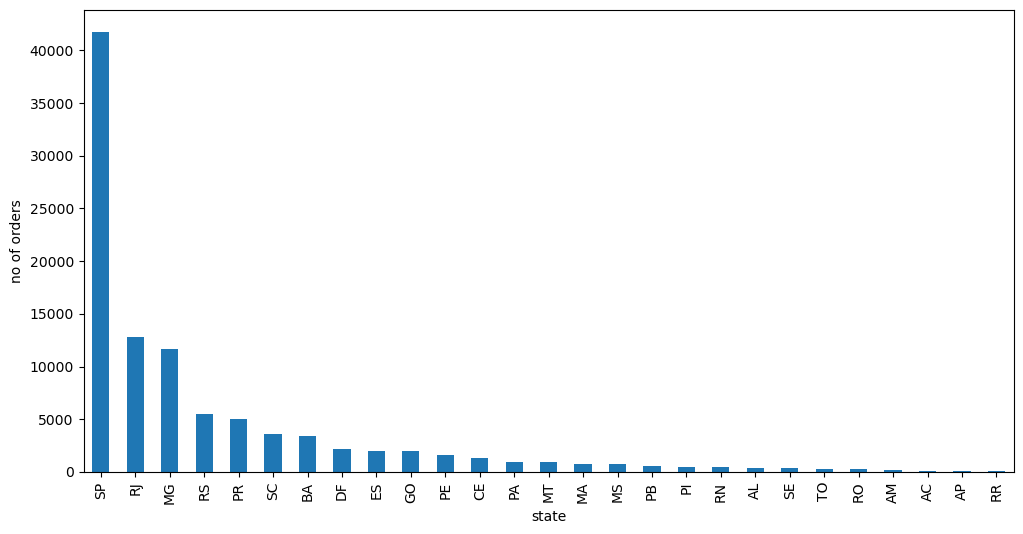

In [37]:
plt.figure(figsize=(12,6))
orders_by_state_df.plot(kind="bar")
plt.xlabel("state")
plt.ylabel("no of orders")
plt.show()

In [38]:
orders_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0
...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,8.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,22.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,24.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0


In [39]:
orders_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0
...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,8.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,22.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,24.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0


In [40]:
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date']) 
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'])

In [41]:
delay = orders_df['order_delivered_customer_date'] - orders_df['order_estimated_delivery_date']

In [42]:
orders_df['delay'] = delay

In [43]:
# converting the daytime to early or late

orders_df["delivery_status"] = orders_df["delay"].apply(
    lambda x: "Early" if x < pd.Timedelta(0)
    else ("On Time" if x == pd.Timedelta(0) else "Late")
)

In [44]:
Delay_review = orders_df.merge(
    order_reviews_df[["order_id","review_score"]],
    on="order_id",
    how="left"
)

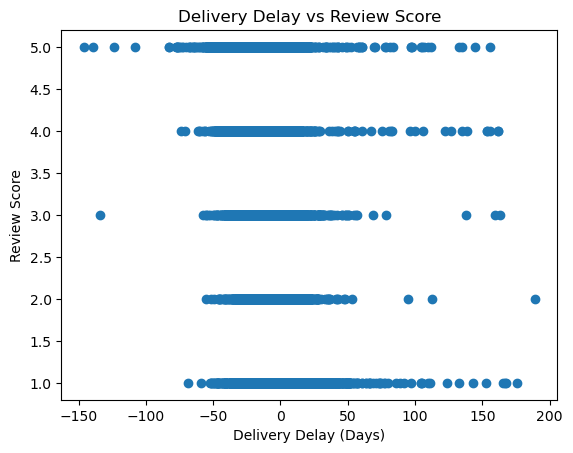

In [45]:
plt.scatter(Delay_review["delay"].dt.total_seconds() / 86400,
            Delay_review["review_score"])

plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Review Score")
plt.title("Delivery Delay vs Review Score")

plt.show()

NameError: name 'category_revenue' is not defined

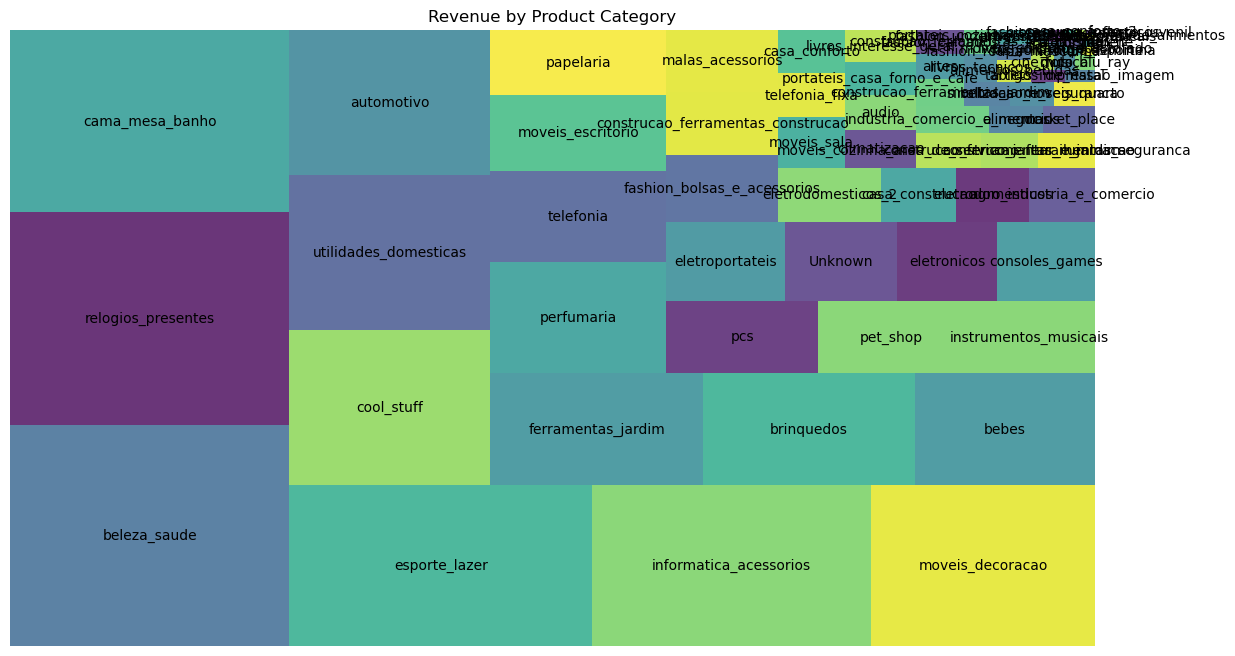

In [49]:
# Merge order items with product categories  i copied this one from chatgpt
category_df = order_items_df.merge(
    products_df[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

# Calculate revenue by category
category_revenue = category_df.groupby(
    "product_category_name"
)["price"].sum().sort_values(ascending=False)

# Treemap
import matplotlib.pyplot as plt
import squarify

plt.figure(figsize=(14, 8))

squarify.plot(
    sizes=category_revenue.values,
    label=category_revenue.index,
    alpha=0.8
)

plt.title("Revenue by Product Category")
plt.axis("off")
plt.show()

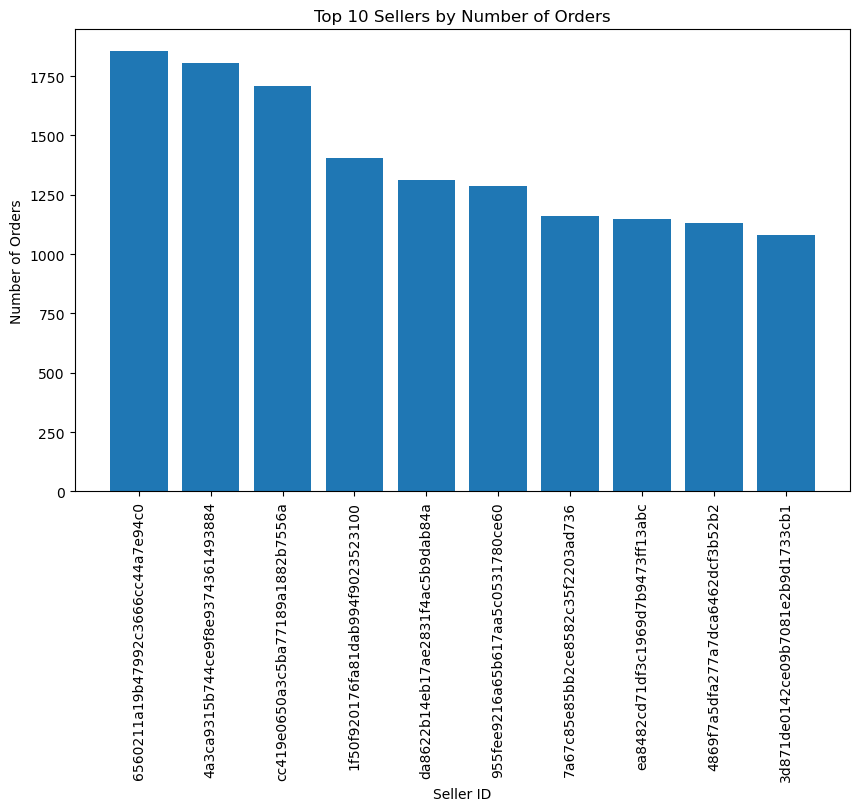

In [50]:
seller_orders = order_items_df.groupby(
    "seller_id"
)["order_id"].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))

plt.bar(seller_orders.index, seller_orders.values)

plt.xlabel("Seller ID")
plt.ylabel("Number of Orders")
plt.title("Top 10 Sellers by Number of Orders")

plt.xticks(rotation=90)
plt.show()

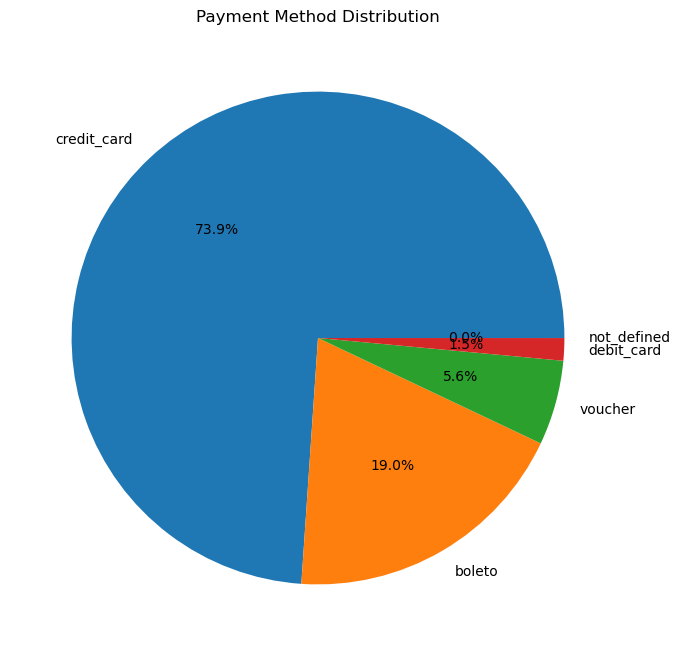

In [51]:
payment_counts = order_payments_df["payment_type"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Payment Method Distribution")
plt.show()

In [52]:
#task 3


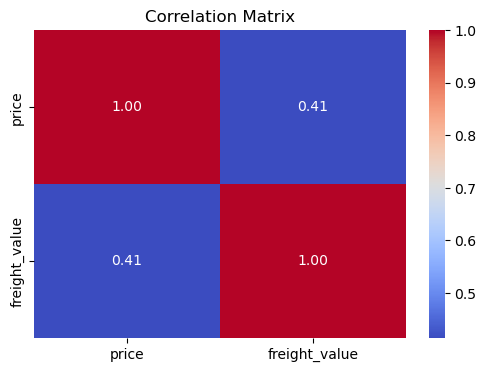

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = order_items_df[["price", "freight_value"]].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

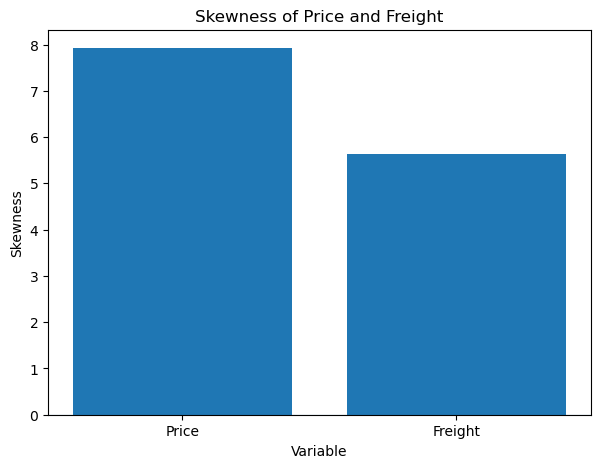

In [58]:
skewness = [
    order_items_df["price"].skew(),
    order_items_df["freight_value"].skew()
]

labels = ["Price", "Freight"]

plt.figure(figsize=(7, 5))
plt.bar(labels, skewness)

plt.xlabel("Variable")
plt.ylabel("Skewness")
plt.title("Skewness of Price and Freight")

plt.axhline(0, linewidth=0.8)
plt.show()

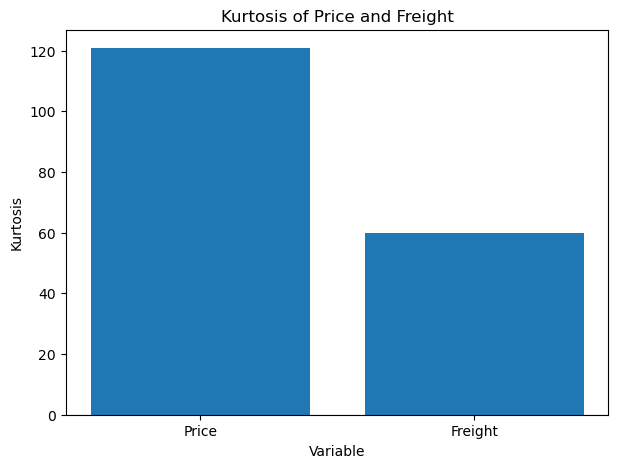

In [59]:
kurtosis = [
    order_items_df["price"].kurt(),
    order_items_df["freight_value"].kurt()
]

labels = ["Price", "Freight"]

plt.figure(figsize=(7, 5))
plt.bar(labels, kurtosis)

plt.xlabel("Variable")
plt.ylabel("Kurtosis")
plt.title("Kurtosis of Price and Freight")

plt.axhline(0, linewidth=0.8)
plt.show()